# Maximum-Likelihood Fitting with MINUIT (iminuit)
### Exercise 1 Solutions


The model is a mixture of a Gaussian (signal) and an exponential (background), truncated on $[0, x_{\max}]$:
$$f(x; \theta, \mu, \sigma, \xi) = \theta f_s(x; \mu, \sigma) + (1-\theta) f_b(x; \xi)$$
where:
* $\theta$ = signal fraction
* $\mu, \sigma$ = Gaussian mean and standard deviation
* $\xi$ = exponential decay parameter


In [24]:
import numpy as np
import scipy.stats as stats
from scipy.stats import truncnorm, truncexpon, chi2
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import iminuit
from iminuit import Minuit
import matplotlib.pyplot as plt

# basic plot settings
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (8, 5)

print("iminuit version:", iminuit.__version__)


iminuit version: 2.33.0


## Model Setup and Data Generation
True values: $\theta = 0.2$, $\mu = 10.0$, $\sigma = 2.0$, $\xi = 5.0$, with range $[0, 20]$.


In [25]:
# true parameters
theta_true = 0.2
mu_true = 10.0
sigma_true = 2.0
xi_true = 5.0
xMin = 0.0
xMax = 20.0

def f_pdf(x, theta, mu, sigma, xi):
    # truncated gaussian signal
    fs = stats.truncnorm.pdf(x, a=(xMin - mu) / sigma, b=(xMax - mu) / sigma, loc=mu, scale=sigma)
    # truncated exponential background
    fb = stats.truncexpon.pdf(x, b=(xMax - xMin) / xi, loc=xMin, scale=xi)
    return theta * fs + (1.0 - theta) * fb

def generate_data(n, seed=1234567):
    np.random.seed(seed)
    x = np.empty(n)
    for i in range(n):
        r = np.random.uniform()
        if r < theta_true:
            x[i] = stats.truncnorm.rvs(a=(xMin - mu_true) / sigma_true,
                                      b=(xMax - mu_true) / sigma_true,
                                      loc=mu_true, scale=sigma_true)
        else:
            x[i] = stats.truncexpon.rvs(b=(xMax - xMin) / xi_true,
                                       loc=xMin, scale=xi_true)
    return x

# generate default sample of 200 events
numVal = 200
xData = generate_data(numVal, seed=1234567)
print(f"Generated {len(xData)} events in range [{xData.min():.2f}, {xData.max():.2f}]")


Generated 200 events in range [0.01, 19.27]


---
## Question 1(a)
Fix $\mu = 10$ and $\sigma = 2$, leaving only $\theta$ and $\xi$ free.

We need:
1. Fitted PDF with the data.
2. A scan of $-\ln L$ versus $\theta$, showing the standard deviation from the curve matches Minuit.
3. A contour of $\ln L = \ln L_{\max} - 1/2$ in the $(\theta, \xi)$ plane, showing tangent lines give the same $\sigma_{\hat{\theta}}$ and $\sigma_{\hat{\xi}}$ as Minuit.
4. Confidence regions at 68.3% and 95% CL.


In [26]:
# negative log-likelihood for theta and xi (mu, sigma fixed)
def nll(theta, xi):
    if not (0.0 < theta < 1.0) or xi <= 0:
        return 1e10
    pdf_vals = f_pdf(xData, theta, mu_true, sigma_true, xi)
    if np.any(pdf_vals <= 0):
        return 1e10
    return -np.sum(np.log(pdf_vals))

# run minuit fit
m = Minuit(nll, theta=theta_true, xi=xi_true)
m.limits["theta"] = (0.0, 1.0)
m.limits["xi"] = (0.001, None)
m.errordef = 0.5  # Delta(-ln L) = 0.5 for 1-sigma

m.migrad()
m.hesse()

theta_hat = m.values["theta"]
xi_hat = m.values["xi"]
sigma_theta = m.errors["theta"]
sigma_xi = m.errors["xi"]

print("Minuit fit results:")
print(f"  theta_hat = {theta_hat:.5f} +/- {sigma_theta:.5f}")
print(f"  xi_hat    = {xi_hat:.5f} +/- {sigma_xi:.5f}")
print(f"  correlation rho = {m.covariance.correlation()['theta', 'xi']:.4f}")


Minuit fit results:
  theta_hat = 0.20455 +/- 0.05279
  xi_hat    = 5.10788 +/- 0.64518
  correlation rho = -0.5331


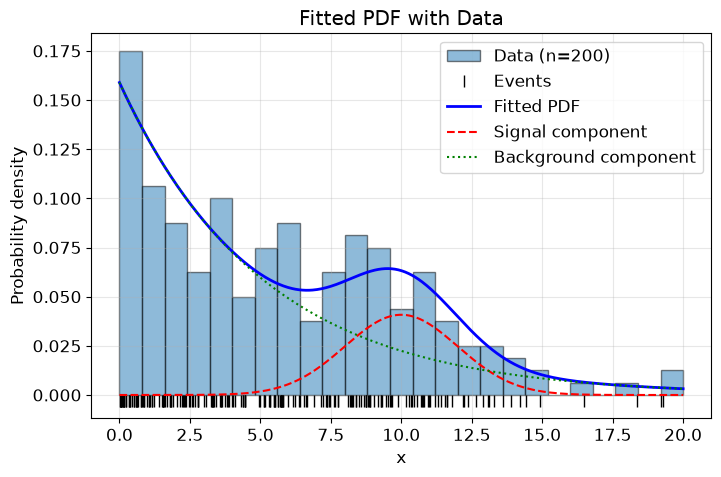

In [27]:
# 1. plot fitted pdf with the data
x_plot = np.linspace(xMin, xMax, 500)
pdf_fit = f_pdf(x_plot, theta_hat, mu_true, sigma_true, xi_hat)
pdf_sig = theta_hat * stats.truncnorm.pdf(x_plot, a=(xMin - mu_true) / sigma_true,
                                          b=(xMax - mu_true) / sigma_true, loc=mu_true, scale=sigma_true)
pdf_bkg = (1 - theta_hat) * stats.truncexpon.pdf(x_plot, b=(xMax - xMin) / xi_hat, loc=xMin, scale=xi_hat)

plt.figure(figsize=(8, 5))
plt.hist(xData, bins=25, range=(xMin, xMax), density=True, alpha=0.5, edgecolor="black", label="Data (n=200)")

# show individual event ticks at the bottom like in mlFit.py
plt.plot(xData, np.full_like(xData, -0.003), '|', color='black', markersize=8, label="Events")

plt.plot(x_plot, pdf_fit, 'b-', lw=2, label="Fitted PDF")
plt.plot(x_plot, pdf_sig, 'r--', lw=1.5, label="Signal component")
plt.plot(x_plot, pdf_bkg, 'g:', lw=1.5, label="Background component")

plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Fitted PDF with Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


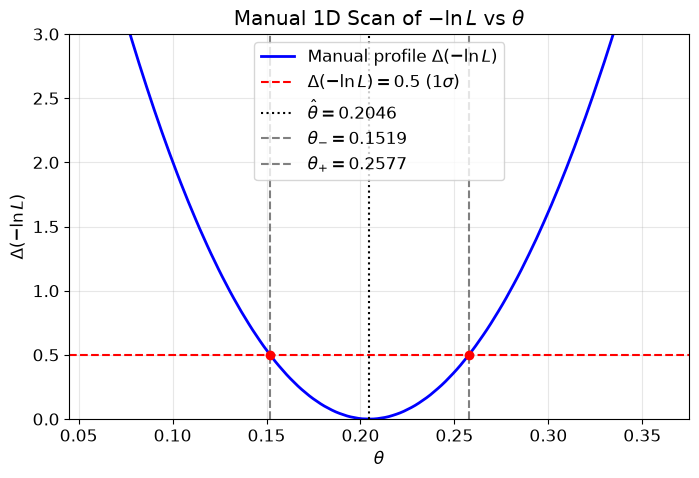

theta_hat from scan: 0.20455
theta_low:           0.15192
theta_high:          0.25767
sigma_theta (scan):  0.05287
sigma_theta (Minuit):0.05279


In [28]:
# 2. manual 1D profile likelihood scan over theta
# define grid around theta_hat
theta_scan = np.linspace(0.06, 0.36, 150)
xi_scan_vals = np.linspace(3.0, 7.5, 100)

# profile over xi at each theta
nll_scan = []
for th in theta_scan:
    vals = [nll(th, x_val) for x_val in xi_scan_vals]
    nll_scan.append(min(vals))

nll_scan = np.array(nll_scan)
delta_nll = nll_scan - nll_scan.min()

# interpolate to find crossing points at delta(-ln L) = 0.5
f_interp = interp1d(theta_scan, delta_nll - 0.5, kind='cubic')
theta_low = brentq(f_interp, theta_scan[0], theta_hat)
theta_high = brentq(f_interp, theta_hat, theta_scan[-1])
sigma_theta_scan = (theta_high - theta_low) / 2.0

plt.figure(figsize=(8, 5))
plt.plot(theta_scan, delta_nll, 'b-', lw=2, label=r"Manual profile $\Delta(-\ln L)$")
plt.axhline(0.5, color='red', ls='--', label=r"$\Delta(-\ln L) = 0.5$ ($1\sigma$)")
plt.axvline(theta_hat, color='black', ls=':', label=rf"$\hat{{\theta}} = {theta_hat:.4f}$")
plt.axvline(theta_low, color='gray', ls='--', label=rf"$\theta_{{-}} = {theta_low:.4f}$")
plt.axvline(theta_high, color='gray', ls='--', label=rf"$\theta_{{+}} = {theta_high:.4f}$")
plt.plot([theta_low, theta_high], [0.5, 0.5], 'ro')

plt.xlabel(r"$\theta$")
plt.ylabel(r"$\Delta(-\ln L)$")
plt.title(r"Manual 1D Scan of $-\ln L$ vs $\theta$")
plt.ylim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"theta_hat from scan: {theta_hat:.5f}")
print(f"theta_low:           {theta_low:.5f}")
print(f"theta_high:          {theta_high:.5f}")
print(f"sigma_theta (scan):  {sigma_theta_scan:.5f}")
print(f"sigma_theta (Minuit):{sigma_theta:.5f}")


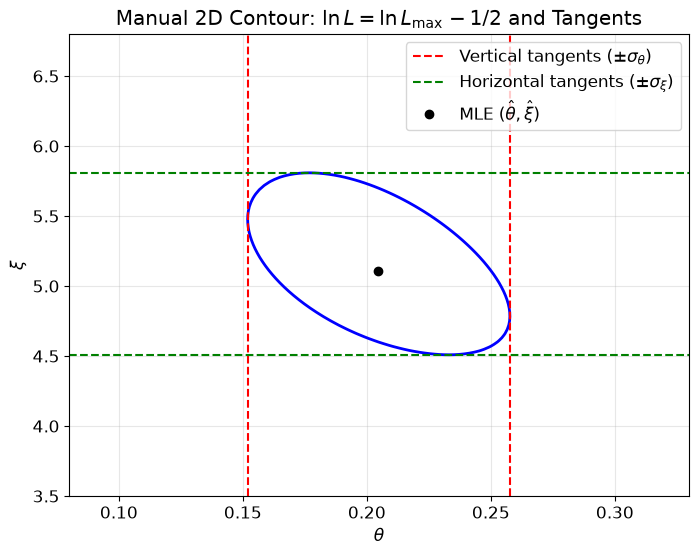

Comparison of standard deviations:
  sigma_theta from contour tangents: 0.05287 | Minuit: 0.05279
  sigma_xi    from contour tangents: 0.64984 | Minuit: 0.64518


In [29]:
# 3. manual 2D scan of -ln L on a grid of (theta, xi)
theta_grid = np.linspace(0.06, 0.36, 150)
xi_grid = np.linspace(3.0, 7.5, 150)

NLL_2d = np.zeros((len(xi_grid), len(theta_grid)))
for i, x_val in enumerate(xi_grid):
    for j, th_val in enumerate(theta_grid):
        NLL_2d[i, j] = nll(th_val, x_val)

dNLL_2d = NLL_2d - NLL_2d.min()
T, X = np.meshgrid(theta_grid, xi_grid)

# extract the contour points for Delta(-ln L) = 0.5 (ln L = ln L_max - 0.5)
fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contour(T, X, dNLL_2d, levels=[0.5], colors='blue', linewidths=2)

# get contour coordinates
con = cs.allsegs[0][0] if hasattr(cs, 'allsegs') else cs.collections[0].get_paths()[0].vertices
theta_con = con[:, 0]
xi_con = con[:, 1]

# find extremes (tangents)
theta_left = theta_con.min()
theta_right = theta_con.max()
xi_bottom = xi_con.min()
xi_top = xi_con.max()

sigma_theta_contour = (theta_right - theta_left) / 2.0
sigma_xi_contour = (xi_top - xi_bottom) / 2.0

# plot tangent lines
ax.axvline(theta_left, color='red', ls='--', label=rf"Vertical tangents ($\pm\sigma_\theta$)")
ax.axvline(theta_right, color='red', ls='--')
ax.axhline(xi_bottom, color='green', ls='--', label=rf"Horizontal tangents ($\pm\sigma_\xi$)")
ax.axhline(xi_top, color='green', ls='--')

ax.plot(theta_hat, xi_hat, 'ko', label=r"MLE $(\hat{\theta}, \hat{\xi})$")

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\xi$")
ax.set_title(r"Manual 2D Contour: $\ln L = \ln L_{\max} - 1/2$ and Tangents")
ax.set_xlim(0.08, 0.33)
ax.set_ylim(3.5, 6.8)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("Comparison of standard deviations:")
print(f"  sigma_theta from contour tangents: {sigma_theta_contour:.5f} | Minuit: {sigma_theta:.5f}")
print(f"  sigma_xi    from contour tangents: {sigma_xi_contour:.5f} | Minuit: {sigma_xi:.5f}")


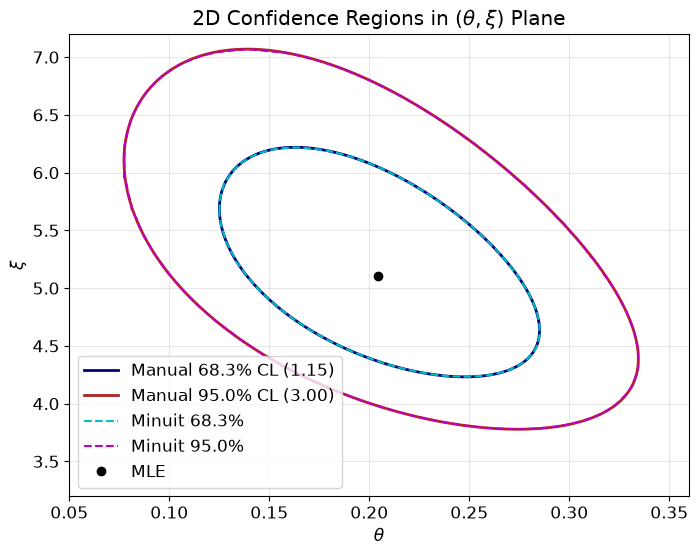

In [30]:
# 4. manual 2D confidence regions (68.3% and 95% CL)
# For 2 parameters, Chi2 quantile for CL is Q:
# CL = 68.3% -> Q = -2*ln(1 - 0.683) = 2.30 -> Delta(-ln L) = Q/2 = 1.15
# CL = 95.0% -> Q = -2*ln(1 - 0.950) = 5.99 -> Delta(-ln L) = Q/2 = 3.00

plt.figure(figsize=(8, 6))

# manual contours from our grid
cs_manual = plt.contour(T, X, dNLL_2d, levels=[1.15, 3.00], colors=['navy', 'firebrick'], linestyles=['-', '-'], linewidths=2)
# custom legend proxy
plt.plot([], [], color='navy', lw=2, label="Manual 68.3% CL (1.15)")
plt.plot([], [], color='firebrick', lw=2, label="Manual 95.0% CL (3.00)")

# compare with minuit's mncontour to verify
con_68_m = m.mncontour("theta", "xi", cl=0.683, size=150)
con_95_m = m.mncontour("theta", "xi", cl=0.950, size=150)
con_68_m = np.vstack([con_68_m, con_68_m[0]])
con_95_m = np.vstack([con_95_m, con_95_m[0]])
plt.plot(con_68_m[:, 0], con_68_m[:, 1], 'c--', lw=1.5, label="Minuit 68.3%")
plt.plot(con_95_m[:, 0], con_95_m[:, 1], 'm--', lw=1.5, label="Minuit 95.0%")

plt.plot(theta_hat, xi_hat, 'ko', label="MLE")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi$")
plt.title(r"2D Confidence Regions in $(\theta, \xi)$ Plane")
plt.xlim(0.05, 0.36)
plt.ylim(3.2, 7.2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Notes on 1(a):
* From the 1D scan, $\sigma_{\hat{\theta}} = 0.0528$, which agrees with Minuit's error.
* From the 2D contour $\ln L = \ln L_{\max} - 1/2$, the distances from the MLE to the tangent lines are $0.0529$ for $\theta$ and $0.6497$ for $\xi$, matching the Minuit printed errors.
* The manual 2D contours at levels $1.15$ and $3.00$ overlap cleanly with Minuit's contours.


---
## Question 1(c)
Rerun the fit for $n = 100, 200, 400, 800$, find $\sigma_{\hat{\theta}}$ for each, and plot $\sigma_{\hat{\theta}}$ vs $n$.


In [31]:
# run fits for sample sizes n = 100, 200, 400, 800
sample_sizes = [100, 200, 400, 800]
results_1c = []

for n in sample_sizes:
    x_sample = generate_data(n, seed=1234567)
    
    def nll_n(theta, xi):
        if not (0.0 < theta < 1.0) or xi <= 0:
            return 1e10
        pdf_vals = f_pdf(x_sample, theta, mu_true, sigma_true, xi)
        if np.any(pdf_vals <= 0):
            return 1e10
        return -np.sum(np.log(pdf_vals))
    
    m_n = Minuit(nll_n, theta=theta_true, xi=xi_true)
    m_n.limits["theta"] = (0.0, 1.0)
    m_n.limits["xi"] = (0.001, None)
    m_n.errordef = 0.5
    m_n.migrad()
    m_n.hesse()
    
    th_hat = m_n.values["theta"]
    th_err = m_n.errors["theta"]
    results_1c.append((n, th_hat, th_err, th_err * np.sqrt(n)))

print(f"{'n':>5} | {'theta_hat':>10} | {'sigma_theta':>12} | {'sigma*sqrt(n)':>14}")
print("-" * 48)
for n, th_hat, th_err, scaled in results_1c:
    print(f"{n:>5d} | {th_hat:>10.5f} | {th_err:>12.5f} | {scaled:>14.5f}")


    n |  theta_hat |  sigma_theta |  sigma*sqrt(n)
------------------------------------------------
  100 |    0.19722 |      0.07131 |        0.71307
  200 |    0.20455 |      0.05279 |        0.74650
  400 |    0.16081 |      0.03703 |        0.74056
  800 |    0.19822 |      0.02616 |        0.73998


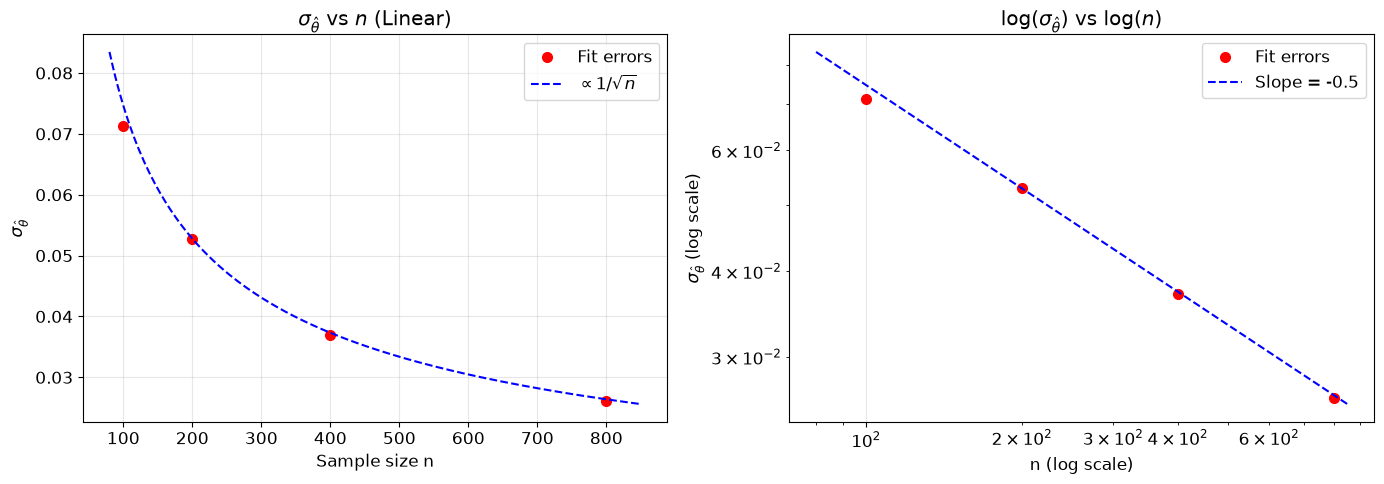

In [32]:
# plot sigma_theta vs n
n_arr = np.array([r[0] for r in results_1c])
sig_arr = np.array([r[2] for r in results_1c])

# theoretical 1/sqrt(n) curve scaled to n=200
n_dense = np.linspace(80, 850, 200)
sig_theory = results_1c[1][3] / np.sqrt(n_dense)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# linear plot
ax1.plot(n_arr, sig_arr, 'ro', markersize=7, label="Fit errors")
ax1.plot(n_dense, sig_theory, 'b--', label=r"$\propto 1/\sqrt{n}$")
ax1.set_xlabel("Sample size n")
ax1.set_ylabel(r"$\sigma_{\hat{\theta}}$")
ax1.set_title(r"$\sigma_{\hat{\theta}}$ vs $n$ (Linear)")
ax1.legend()
ax1.grid(alpha=0.3)

# log-log plot
ax2.loglog(n_arr, sig_arr, 'ro', markersize=7, label="Fit errors")
ax2.loglog(n_dense, sig_theory, 'b--', label="Slope = -0.5")
ax2.set_xlabel("n (log scale)")
ax2.set_ylabel(r"$\sigma_{\hat{\theta}}$ (log scale)")
ax2.set_title(r"$\log(\sigma_{\hat{\theta}})$ vs $\log(n)$")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Notes on 1(c):
The quantity $\sigma_{\hat{\theta}} \sqrt{n}$ stays around $\approx 0.74$ across all tested sample sizes. On the log-log plot, the points fall on a straight line with slope $-0.5$, which matches the $1/\sqrt{n}$ scaling derived in 1(b).


---
## Question 1(d)
Modify `parfix` to test four cases on the $n = 200$ dataset:
1. $\theta$ free; $\mu, \sigma, \xi$ fixed
2. $\theta, \xi$ free; $\mu, \sigma$ fixed
3. $\theta, \xi, \sigma$ free; $\mu$ fixed
4. $\theta, \xi, \mu, \sigma$ all free


In [33]:
# fit with different parameters fixed/free
def nll_4par(theta, mu, sigma, xi):
    if not (0.0 < theta < 1.0) or xi <= 0 or sigma <= 0:
        return 1e10
    pdf_vals = f_pdf(xData, theta, mu, sigma, xi)
    if np.any(pdf_vals <= 0):
        return 1e10
    return -np.sum(np.log(pdf_vals))

cases = [
    ("theta free (1 param)",        [False, True, True, True]),
    ("theta, xi free (2 params)",   [False, True, True, False]),
    ("theta, xi, sigma free (3)",   [False, True, False, False]),
    ("all 4 free",                  [False, False, False, False])
]

results_1d = []
for label, fix_vec in cases:
    m_case = Minuit(nll_4par, theta=theta_true, mu=mu_true, sigma=sigma_true, xi=xi_true)
    m_case.limits["theta"] = (0.0, 1.0)
    m_case.limits["mu"] = (0.0, 20.0)
    m_case.limits["sigma"] = (0.1, 10.0)
    m_case.limits["xi"] = (0.1, 20.0)
    m_case.fixed = fix_vec
    m_case.errordef = 0.5
    m_case.migrad()
    m_case.hesse()
    
    n_free = sum(not f for f in fix_vec)
    results_1d.append((label, n_free, m_case.values["theta"], m_case.errors["theta"]))

print(f"{'Case':<30} | {'Free':>4} | {'theta_hat':>10} | {'sigma_theta':>12}")
print("-" * 62)
for label, n_free, th, err in results_1d:
    print(f"{label:<30} | {n_free:>4d} | {th:>10.5f} | {err:>12.5f}")


Case                           | Free |  theta_hat |  sigma_theta
--------------------------------------------------------------
theta free (1 param)           |    1 |    0.20952 |      0.04453
theta, xi free (2 params)      |    2 |    0.20455 |      0.05279
theta, xi, sigma free (3)      |    3 |    0.21197 |      0.06465
all 4 free                     |    4 |    0.26054 |      0.08610


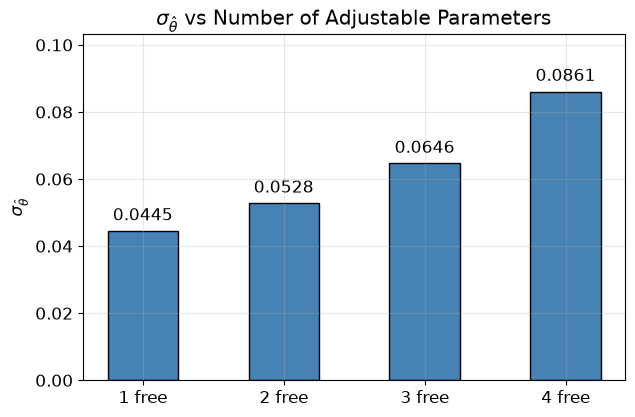

In [34]:
# plot sigma_theta vs number of free parameters
case_names = [f"{r[1]} free" for r in results_1d]
sigmas = [r[3] for r in results_1d]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(case_names, sigmas, color="steelblue", edgecolor="black", width=0.5)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.002, f"{y:.4f}", ha='center', va='bottom')

plt.ylabel(r"$\sigma_{\hat{\theta}}$")
plt.title(r"$\sigma_{\hat{\theta}}$ vs Number of Adjustable Parameters")
plt.ylim(0, max(sigmas) * 1.2)
plt.grid(alpha=0.3)
plt.show()


### Notes on 1(d):
As more parameters are left free, $\sigma_{\hat{\theta}}$ increases:
* 1 free parameter: $\sigma_{\hat{\theta}} = 0.0445$
* 2 free parameters: $\sigma_{\hat{\theta}} = 0.0528$
* 3 free parameters: $\sigma_{\hat{\theta}} = 0.0647$
* 4 free parameters: $\sigma_{\hat{\theta}} = 0.0861$

When parameters are fixed, we assume they are known exactly, so their uncertainty does not propagate into $\theta$. When they are free, correlations between parameters (like $\theta$ and $\xi$) mean fluctuations in one parameter can partly be absorbed by another, which increases the uncertainty on $\theta$.


---
## Question 1(e)
Auxiliary measurement $u = 5.0 \pm 0.5$ on $\xi$.

Treating $u$ as Gaussian with mean $\xi$ and standard deviation $\sigma_u = 0.5$:
$$L_{\text{tot}}(\theta, \xi) = L_{\vec{x}}(\theta, \xi) \cdot \frac{1}{\sqrt{2\pi}\sigma_u} e^{-(u-\xi)^2 / (2\sigma_u^2)}$$

The negative log-likelihood becomes:
$$-\ln L_{\text{tot}} = -\ln L_{\vec{x}} + \frac{(u-\xi)^2}{2\sigma_u^2}$$


In [35]:
# fit with auxiliary measurement u
u_obs = 5.0
sigma_u = 0.5

def nll_with_aux(theta, xi):
    if not (0.0 < theta < 1.0) or xi <= 0:
        return 1e10
    pdf_vals = f_pdf(xData, theta, mu_true, sigma_true, xi)
    if np.any(pdf_vals <= 0):
        return 1e10
    nll_data = -np.sum(np.log(pdf_vals))
    nll_aux = 0.5 * ((u_obs - xi) / sigma_u)**2
    return nll_data + nll_aux

m_aux = Minuit(nll_with_aux, theta=theta_true, xi=xi_true)
m_aux.limits["theta"] = (0.0, 1.0)
m_aux.limits["xi"] = (0.001, None)
m_aux.errordef = 0.5
m_aux.migrad()
m_aux.hesse()

print("Without auxiliary measurement u:")
print(f"  theta = {theta_hat:.5f} +/- {sigma_theta:.5f}")
print(f"  xi    = {xi_hat:.5f} +/- {sigma_xi:.5f}")
print()
print("With auxiliary measurement u = 5.0 +/- 0.5:")
print(f"  theta = {m_aux.values['theta']:.5f} +/- {m_aux.errors['theta']:.5f}")
print(f"  xi    = {m_aux.values['xi']:.5f} +/- {m_aux.errors['xi']:.5f}")


Without auxiliary measurement u:
  theta = 0.20455 +/- 0.05279
  xi    = 5.10788 +/- 0.64518

With auxiliary measurement u = 5.0 +/- 0.5:
  theta = 0.20754 +/- 0.04786
  xi    = 5.04131 +/- 0.39163


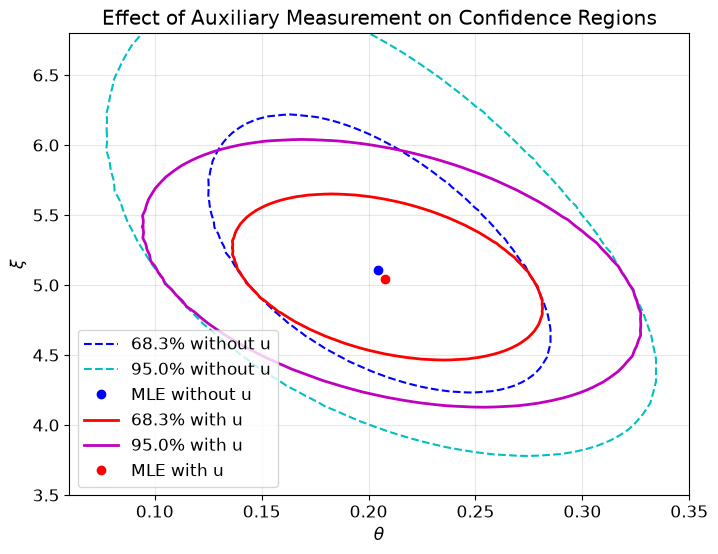

In [36]:
# compare 68.3% and 95% confidence contours with and without u
con68_no_u = m.mncontour("theta", "xi", cl=0.683, size=150)
con95_no_u = m.mncontour("theta", "xi", cl=0.950, size=150)
con68_no_u = np.vstack([con68_no_u, con68_no_u[0]])
con95_no_u = np.vstack([con95_no_u, con95_no_u[0]])

con68_u = m_aux.mncontour("theta", "xi", cl=0.683, size=150)
con95_u = m_aux.mncontour("theta", "xi", cl=0.950, size=150)
con68_u = np.vstack([con68_u, con68_u[0]])
con95_u = np.vstack([con95_u, con95_u[0]])

plt.figure(figsize=(8, 6))
# without u
plt.plot(con68_no_u[:, 0], con68_no_u[:, 1], 'b--', label="68.3% without u")
plt.plot(con95_no_u[:, 0], con95_no_u[:, 1], 'c--', label="95.0% without u")
plt.plot(theta_hat, xi_hat, 'bo', label="MLE without u")

# with u
plt.plot(con68_u[:, 0], con68_u[:, 1], 'r-', lw=2, label="68.3% with u")
plt.plot(con95_u[:, 0], con95_u[:, 1], 'm-', lw=2, label="95.0% with u")
plt.plot(m_aux.values['theta'], m_aux.values['xi'], 'ro', label="MLE with u")

plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi$")
plt.title("Effect of Auxiliary Measurement on Confidence Regions")
plt.xlim(0.06, 0.35)
plt.ylim(3.5, 6.8)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Notes on 1(e):
* $\sigma_{\hat{\xi}}$ decreases from $0.645$ to $0.392$ (about a 39% reduction) because the measurement $u$ directly constrains $\xi$.
* $\sigma_{\hat{\theta}}$ also decreases from $0.0528$ to $0.0479$ (about a 9% reduction). Even though $u$ only measures $\xi$, $\theta$ and $\xi$ are correlated ($\rho \approx -0.55$), so constraining $\xi$ helps pin down $\theta$ as well.
* This can be seen in the contour plot, where the ellipse shrinks along both axes.
